In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer

In [26]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\riders - riders.csv (2).csv")

In [27]:
df2=pd.read_json(r"C:\Users\Admin\Downloads\trips.json")

In [28]:
df.isnull().sum()

rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         300 non-null    object 
 1   name             300 non-null    object 
 2   age              300 non-null    int64  
 3   gender           300 non-null    object 
 4   city             300 non-null    object 
 5   signup_date      300 non-null    object 
 6   total_rides      300 non-null    int64  
 7   cancelled_rides  300 non-null    int64  
 8   avg_rating       300 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 21.2+ KB


In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       2000 non-null   object 
 1   rider_id      2000 non-null   object 
 2   zone          2000 non-null   object 
 3   distance_km   2000 non-null   float64
 4   duration_min  2000 non-null   float64
 5   fare_amount   2000 non-null   float64
 6   payment_mode  2000 non-null   object 
 7   ride_date     2000 non-null   object 
 8   surge_flag    2000 non-null   int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 140.8+ KB


# TASK 2

In [12]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

mean_imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = mean_imputer.fit_transform(df[numeric_cols])

In [13]:
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

mode_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = mode_imputer.fit_transform(df[categorical_cols])

In [16]:


knn_cols = ['duration_min', 'distance_km', 'fare_amount']

knn = KNNImputer(n_neighbors=5)
df2[knn_cols] = knn.fit_transform(df2[knn_cols])



In [17]:
df2['ride_date'] = pd.to_datetime(df2['ride_date'], errors='coerce')

In [18]:
df2['ride_date'] = pd.to_datetime(df2['ride_date'], errors='coerce', dayfirst=True)

In [19]:
df2 = df2[df2['fare_amount'] >= 0]

# TASK 3

In [20]:


# Before
print("Before rows:", len(df2))

# Z-score filtering
fare_z = (df2['fare_amount'] - df2['fare_amount'].mean()) / df2['fare_amount'].std()
distance_z = (df2['distance_km'] - df2['distance_km'].mean()) / df2['distance_km'].std()

df2 = df2[(abs(fare_z) <= 3) & (abs(distance_z) <= 3)]

# After
print("After Z-score rows:", len(df2))

Before rows: 2000
After Z-score rows: 1981


In [21]:
Q1 = df2['duration_min'].quantile(0.25)
Q3 = df2['duration_min'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Before duration filter:", len(df2))

df2 = df2[(df2['duration_min'] >= lower) & 
          (df2['duration_min'] <= upper)]

print("After IQR rows:", len(df2))

Before duration filter: 1981
After IQR rows: 1971


In [22]:
# Before
print("Fare before:")
print(df2['fare_amount'].describe())

# Cap extreme values
lower_cap = df2['fare_amount'].quantile(0.01)
upper_cap = df2['fare_amount'].quantile(0.99)

df2['fare_amount'] = np.clip(df2['fare_amount'], lower_cap, upper_cap)

# After
print("Fare after:")
print(df2['fare_amount'].describe())

Fare before:
count    1971.000000
mean      131.277453
std        80.850124
min         0.250000
25%        69.790000
50%       120.340000
75%       179.825000
max       390.780000
Name: fare_amount, dtype: float64
Fare after:
count    1971.000000
mean      130.993308
std        79.982922
min         3.192000
25%        69.790000
50%       120.340000
75%       179.825000
max       337.572000
Name: fare_amount, dtype: float64


# TASK 4

In [23]:
df2['ride_date'] = pd.to_datetime(df2['ride_date'], errors='coerce')

df2['hour'] = df2['ride_date'].dt.hour
df2['day_of_week'] = df2['ride_date'].dt.day_name()
df2['month'] = df2['ride_date'].dt.month

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [42]:
cols = ['ride_payment_mode', 'zone_name']

existing_cols = [col for col in cols if col in df.columns]

df = pd.get_dummies(df, columns=existing_cols, drop_first=True)

In [43]:
ride_counts = df2['rider_id'].value_counts()

df2['ride_frequency'] = df2['rider_id'].map(ride_counts)

df2['ride_category'] = pd.cut(
    df2['ride_frequency'],
    bins=[0, 5, 15, df2['ride_frequency'].max()],
    labels=['Low', 'Medium', 'High']
)

In [44]:
import numpy as np

df2['fare_amount'] = np.log1p(df2['fare_amount'])
df2['distance_km'] = np.log1p(df2['distance_km'])

In [45]:
df2['duration_min'] = np.sqrt(df2['duration_min'])

# TASK 5

In [46]:
numeric_cols = df2.select_dtypes(include='number').columns

In [47]:
print("Before Scaling:")
print(df2[numeric_cols].agg(['mean','std','min','max']))

Before Scaling:
      distance_km  duration_min  fare_amount  surge_flag  ride_frequency
mean     2.069138      7.459679     4.628943    0.510500        7.670000
std      0.620352      2.497944     0.894501    0.500015        2.587556
min      0.019803      0.435890     0.223144    0.000000        1.000000
max      3.290638     14.179915     6.159708    1.000000       16.000000


In [48]:
from sklearn.preprocessing import StandardScaler

scaler_std = StandardScaler()
df_std = df2.copy()

df_std[numeric_cols] = scaler_std.fit_transform(df_std[numeric_cols])

print("\nAfter StandardScaler:")
print(df_std[numeric_cols].agg(['mean','std','min','max']))


After StandardScaler:
       distance_km  duration_min   fare_amount    surge_flag  ride_frequency
mean -2.664535e-16  6.217249e-17  4.112266e-16  5.861978e-17    5.684342e-17
std   1.000250e+00  1.000250e+00  1.000250e+00  1.000250e+00    1.000250e+00
min  -3.304328e+00 -2.812531e+00 -4.926661e+00 -1.021225e+00   -2.578366e+00
max   1.969536e+00  2.690980e+00  1.711735e+00  9.792159e-01    3.220059e+00


In [49]:
from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()
df_mm = df2.copy()

df_mm[numeric_cols] = scaler_mm.fit_transform(df_mm[numeric_cols])

print("\nAfter MinMaxScaler:")
print(df_mm[numeric_cols].agg(['mean','std','min','max']))


After MinMaxScaler:
      distance_km  duration_min  fare_amount  surge_flag  ride_frequency
mean     0.626548      0.511043     0.742146    0.510500        0.444667
std      0.189662      0.181748     0.150676    0.500015        0.172504
min      0.000000      0.000000     0.000000    0.000000        0.000000
max      1.000000      1.000000     1.000000    1.000000        1.000000


# TASK 6

In [50]:
avg_distance = df2.groupby('rider_id')['distance_km'].mean()
df2['avg_ride_distance'] = df2['rider_id'].map(avg_distance)

In [51]:
avg_fare = df2.groupby('rider_id')['fare_amount'].mean()
df2['avg_ride_fare'] = df2['rider_id'].map(avg_fare)

In [54]:
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')

today = pd.Timestamp.today()
df['days_since_signup'] = (today - df['signup_date']).dt.days

In [55]:
df2['fare_per_km'] = df2['fare_amount'] / df2['distance_km']

threshold = df2['fare_per_km'].quantile(0.90)

df2['surge_flag'] = (df2['fare_per_km'] > threshold).astype(int)

In [58]:

df_original = df.copy()
df2_original = df2.copy()
missing_before = df2_original.isna().sum().sum()
missing_after = df2.isna().sum().sum()



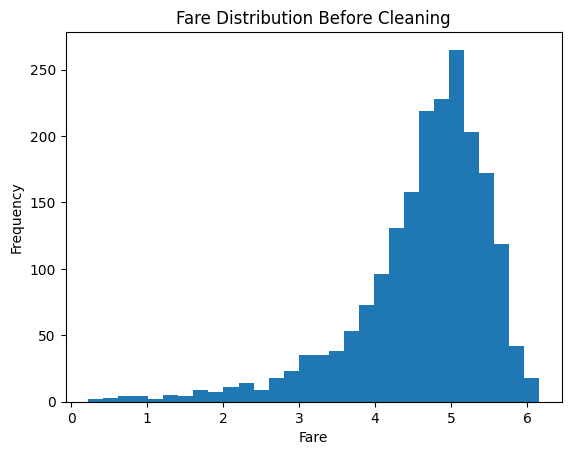

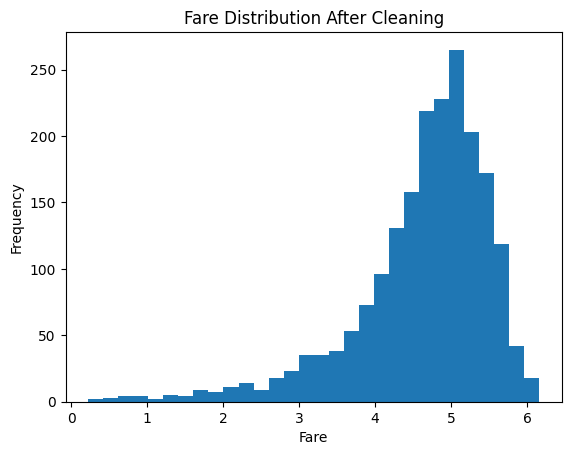

In [ ]:
plt.figure()
plt.hist(df2_original['fare_amount'], bins=30)
plt.title('Fare Distribution Before Cleaning')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

plt.figure()
plt.hist(df2['fare_amount'], bins=30)
plt.title('Fare Distribution After Cleaning')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

Before cleaning, the fare distribution shows extreme values and long tails indicating outliers.
After cleaning, the distribution becomes more compact and consistent, showing that extreme fares were successfully handled.

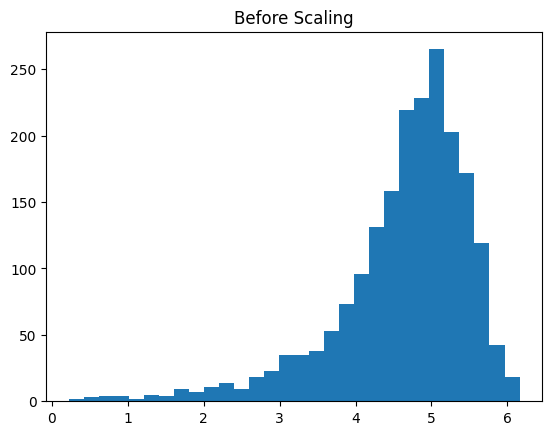

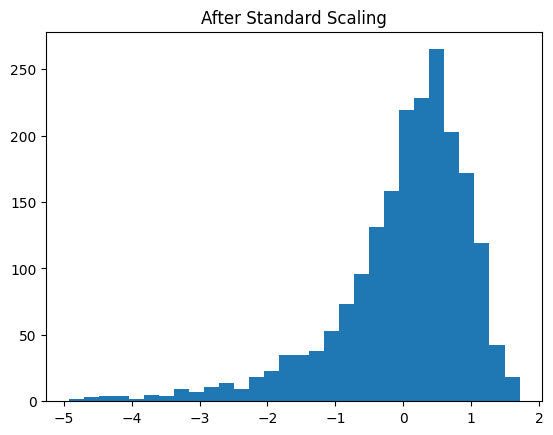

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_before = df2_original[['fare_amount']]
scaled_after = scaler.fit_transform(df2[['fare_amount']])

plt.figure()
plt.hist(scaled_before, bins=30)
plt.title('Before Scaling')
plt.show()

plt.figure()
plt.hist(scaled_after, bins=30)
plt.title('After Standard Scaling')
plt.show()

Before scaling, the feature has a wide range of values with uneven spread.
After applying StandardScaler, the data is centered around 0 with standardized spread, making it suitable for machine learning models."